<a href="https://colab.research.google.com/github/tejasbawane/Maincrafts_Technology_Internship/blob/main/AI_ML_Task4_Classification_Evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    accuracy_score
)

In [2]:
# Load Dataset

data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target  # 0: Malignant, 1: Benign

print(f"Dataset loaded. Features shape: {X.shape}, Target shape: {y.shape}")
print(f"Class distributions - Malignant (0): {np.sum(y == 0)}, Benign (1): {np.sum(y == 1)}\n")

Dataset loaded. Features shape: (569, 30), Target shape: (569,)
Class distributions - Malignant (0): 212, Benign (1): 357



In [3]:
# Train-Test Split with Stratification

# Stratify=y ensures the training and test sets maintain the same class proportions
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Training elements: {X_train.shape[0]}, Testing elements: {X_test.shape[0]}\n")

Training elements: 455, Testing elements: 114



In [4]:
# Feature Scaling

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Feature scaling complete.\n")

Feature scaling complete.



In [5]:
# Train Baseline Classification Model (Logistic Regression)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
print("Baseline model trained successfully.\n")

Baseline model trained successfully.



In [6]:
# Confusion Matrix & Classification Report

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Extracting elements for clarity
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives (Malignant correctly identified): {tn}")
print(f"False Positives (Malignant misclassified as Benign): {fp}")
print(f"False Negatives (Benign misclassified as Malignant): {fn}")
print(f"True Positives (Benign correctly identified): {tp}\n")

Confusion Matrix:
[[41  1]
 [ 1 71]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

True Negatives (Malignant correctly identified): 41
False Positives (Malignant misclassified as Benign): 1
False Negatives (Benign misclassified as Malignant): 1
True Positives (Benign correctly identified): 71



In [7]:
# ROC Curve & AUC Score

y_prob = model.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)
print(f"Baseline Logistic Regression AUC: {auc:.4f}\n")

Baseline Logistic Regression AUC: 0.9954



In [8]:
# Handle Class Imbalance (Using Class Weights)

model_balanced = LogisticRegression(class_weight="balanced", max_iter=1000)
model_balanced.fit(X_train_scaled, y_train)
y_pred_balanced = model_balanced.predict(X_test_scaled)
y_prob_balanced = model_balanced.predict_proba(X_test_scaled)[:, 1]

print("Balanced Model Classification Report:")
print(classification_report(y_test, y_pred_balanced))

Balanced Model Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.98      0.94        42
           1       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



In [9]:
# Compare with Another Classifier (Decision Tree Classifier)

# Using unscaled features as decision trees are scale-invariant
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)
y_pred_tree = tree.predict(X_test)
y_prob_tree = tree.predict_proba(X_test)[:, 1]

print("Decision Tree Classification Report:")
print(classification_report(y_test, y_pred_tree))


Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.93      0.89        42
           1       0.96      0.90      0.93        72

    accuracy                           0.91       114
   macro avg       0.90      0.92      0.91       114
weighted avg       0.92      0.91      0.91       114



In [10]:
# Performance Comparison Summary

print("Final Model Comparison Summary Table: ")
metrics_summary = {
    "Model": ["Baseline Logistic Regression", "Balanced Logistic Regression", "Decision Tree Classifier"],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_balanced),
        accuracy_score(y_test, y_pred_tree)
    ],
    "AUC-ROC": [
        auc,
        roc_auc_score(y_test, y_prob_balanced),
        roc_auc_score(y_test, y_prob_tree)
    ]
}
df_metrics = pd.DataFrame(metrics_summary)
display(df_metrics)
print("\n")

Final Model Comparison Summary Table: 


,Model,Accuracy,AUC-ROC
0,Baseline Logistic Regression,0.982456,0.995370
1,Balanced Logistic Regression,0.956140,0.995370
2,Decision Tree Classifier,0.912281,0.915675


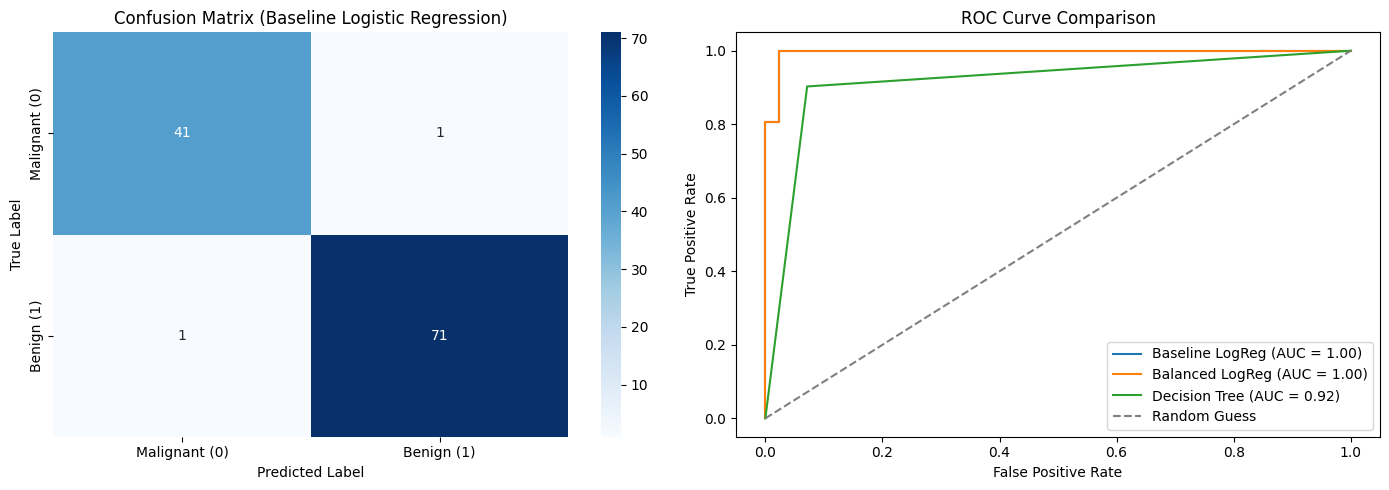

In [11]:
# Required Deliverable Plots (Confusion Matrices & Comparative ROC Curves)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Confusion Matrix Heatmap for Baseline Model
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Malignant (0)', 'Benign (1)'],
            yticklabels=['Malignant (0)', 'Benign (1)'])
axes[0].set_title("Confusion Matrix (Baseline Logistic Regression)")
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")

# Plot 2: ROC Curves Comparison
axes[1].plot(fpr, tpr, label=f"Baseline LogReg (AUC = {auc:.2f})")
fpr_bal, tpr_bal, _ = roc_curve(y_test, y_prob_balanced)
fpr_tree, tpr_tree, _ = roc_curve(y_test, y_prob_tree)
axes[1].plot(fpr_bal, tpr_bal, label=f"Balanced LogReg (AUC = {roc_auc_score(y_test, y_prob_balanced):.2f})")
axes[1].plot(fpr_tree, tpr_tree, label=f"Decision Tree (AUC = {roc_auc_score(y_test, y_prob_tree):.2f})")
axes[1].plot([0, 1], [0, 1], linestyle="--", color='gray', label="Random Guess")

axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve Comparison")
axes[1].legend()

plt.tight_layout()
plt.show()